In [1]:
import numpy as np
from jax import numpy as jnp
from matplotlib import pyplot as plt

from qnn import QNN
from qnn.utils import fourier_coefficients

# Univariate

In [2]:
s_turnpike=[0, 1, 4, 6]
s_golomb=[0, 1, 4, 6]

In [3]:
# Define all necessary models
models = {encoding: QNN(R=4,
                        L=2,
                        N=1,  # Fixed
                        ansatz="sequential",  # Not relevant here
                        encoding=encoding,
                        trainable_block_layers=5,
                        save_weights=True,
                        save_losses=True,
                        max_iter=4_000,
                        step_size=0.05,
                        verbose=True,
                        s = s_turnpike if encoding == "turnpike" else s_golomb if encoding == "golomb" else []
                       ) for encoding in ("hamming", "exponential", "binary", "ternary", "golomb", "turnpike")}

In [4]:
# Here we define a class for a real-valued Fourier series.
class RealFourierSeries:
    def __init__(self, pos_coefficients: list[complex]):
        """
        Takes the  complex coefficients c_0, c_1,... of the Fourier series. The actual series contains c_{-1},...c_{-N}, 
        which is the complex conjugate of the coefficients with a positive index. Note that c_0 has to be real.
        
        The Fourier series is then given by: f(x) = c_0 + \sum_{n=-N}^{N} c_n * exp(i * n * x)
        
        :param pos_coefficients: A list of coefficients.
        """
        neg_coeffs = reversed(pos_coefficients[1:])
        neg_coeffs = [complex(c).conjugate() for c in neg_coeffs]
        self.coefficients = jnp.array(neg_coeffs + pos_coefficients)

    @property
    def size(self) -> int:
        return (len(self.coefficients) - 1) // 2

    def __call__(self, x):
        """
        Evaluates the Fourier series at x. If x is a scalar, the function returns the value of the series at x. If x is a list of values, the function returns f(v) for each value v in x.
        """
        if isinstance(x, (int, float, complex)):
            exponentials = jnp.exp(1j * x * jnp.array(range(-self.size, self.size + 1)))
            return float(jnp.sum(exponentials * self.coefficients).real)
        else:
            exponentials = [jnp.exp(1j * x_ * jnp.array(range(-self.size, self.size + 1))) for x_ in x]
            return jnp.array([jnp.sum(e * self.coefficients).real for e in exponentials])

In [5]:
# Create a random Fourier series (scaled by hand such that f \in [-1, 1])
coeffs = 1 / 100 * np.random.random(size=(20,))
f = RealFourierSeries(list(coeffs))

In [6]:
# Check scaling
x_test = jnp.linspace(0, 2 * jnp.pi, 10_000)
y_test = f(x_test)
min(y_test), max(y_test)

(Array(-0.05205694, dtype=float64), Array(0.16374227, dtype=float64))

In [7]:
coeffs

array([0.00163275, 0.0034771 , 0.00030623, 0.00416477, 0.00744   ,
       0.0098742 , 0.00862984, 0.00338553, 0.00445025, 0.00599347,
       0.00354522, 0.00107512, 0.00486932, 0.00222524, 0.0016781 ,
       0.00428526, 0.00779481, 0.00201263, 0.00401661, 0.00183104])

In [8]:
fourier_coefficients(f, 11).round(3)

Array([0.002+0.j, 0.003+0.j, 0.   +0.j, 0.004+0.j, 0.009+0.j, 0.014-0.j,
       0.011-0.j, 0.011+0.j, 0.009+0.j, 0.008-0.j, 0.006-0.j, 0.006+0.j],      dtype=complex128)

In [9]:
# Create training data
x = jnp.linspace(-jnp.pi, jnp.pi, 100)
y = f(x)

In [10]:
# Train the models
for model in models.values():
    model.fit(x.reshape(-1, 1), y)

Best loss: 0.000000: 100%|████████████████████████████████████████████████████████| 4000/4000 [00:39<00:00, 102.36it/s]


In [11]:
for ansatz, model in models.items():
    print(f"{ansatz=:15} {model.loss_score(x.reshape(-1, 1), y):.6f}")

ansatz=hamming         0.000365
ansatz=exponential     0.000000
ansatz=binary          0.000000
ansatz=ternary         0.000000
ansatz=golomb          0.000000
ansatz=turnpike        0.000000


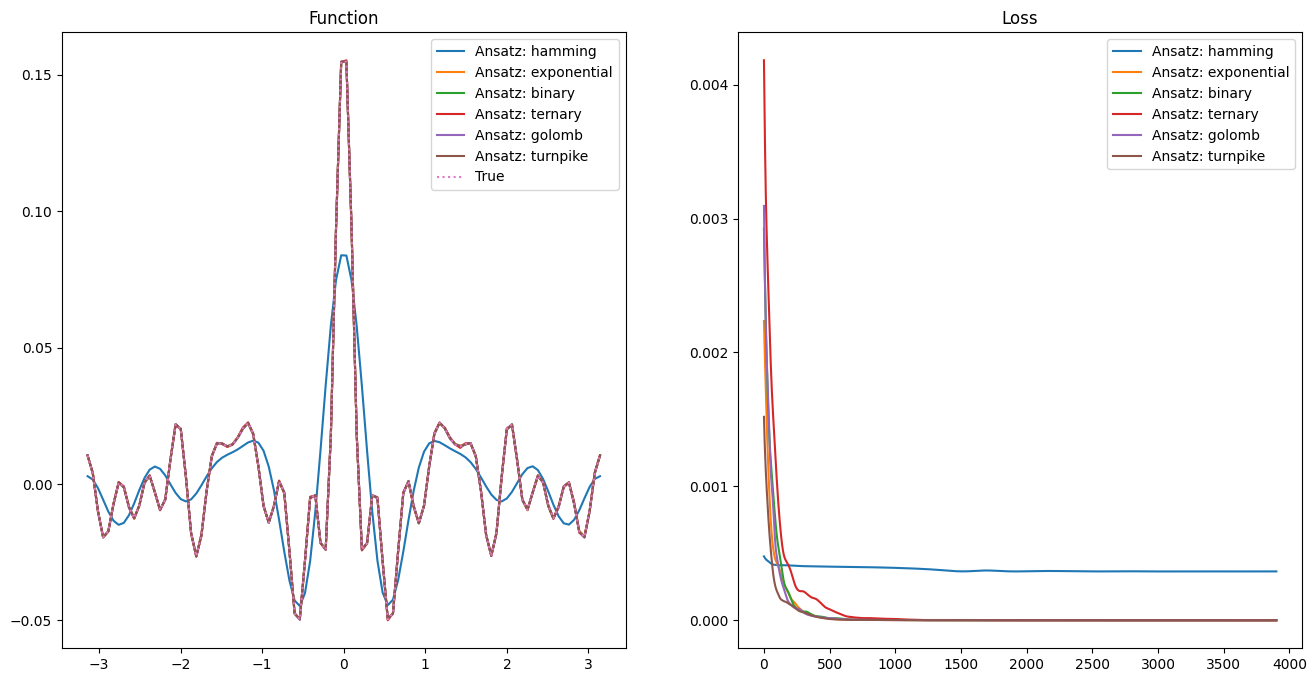

In [12]:
# Plot the results
cutoff = 100
fig, axs = plt.subplots(1, 2, figsize=(16, 8))
for ansatz, model in models.items():
    axs[0].plot(x, model.predict(x.reshape(-1, 1)), label=f"Ansatz: {ansatz}")
    axs[1].plot(range(len(model.losses[cutoff:])), model.losses[cutoff:], label=f"Ansatz: {ansatz}")
axs[0].plot(x, y, label="True", linestyle="dotted")
axs[0].legend()
axs[1].legend()
axs[0].set_title("Function")
axs[1].set_title("Loss")
plt.show()

# MNIST

In [13]:
from sklearn.datasets import fetch_openml

In [14]:
# Load mnist dataset
mnist = fetch_openml("mnist_784", as_frame=False)
mnist_data = mnist.data

In [15]:
def make_quadratic(image_vec):
    """
    Transforms a 784-dimensional vector into a 28x28 image.
    
    :param image_vec: A 784-dimensional vector.
    """
    image = np.zeros((28, 28))
    i = 0
    for x_coord in range(28):
        for y_coord in range(28):
            image[x_coord, y_coord] = image_vec[i]
            i += 1
    return image

In [16]:
# Create the training data
image = np.reshape(mnist_data[0], (28, 28))

X = []
y = []
for x_coord in range(28):
    for y_coord in range(28):
        X.append((x_coord, y_coord))
        y.append(image[x_coord, y_coord] / (2 * 255))
X = np.array(X)
y = np.array(y)

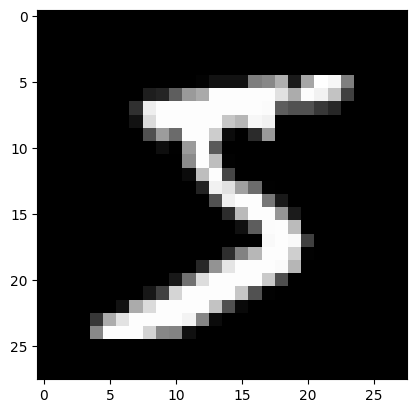

In [17]:
plt.imshow(image, cmap="gray")

In [20]:
models = {(ansatz, encoding): QNN(R=4,
                                  L=4,
                                  N=2,  # Fixed
                                  ansatz=ansatz,
                                  encoding=encoding,
                                  trainable_block_layers=5,
                                  save_weights=True,
                                  save_losses=True,
                                  max_iter=4_000,
                                  step_size=0.5,
                                  verbose=True,
                                  s=s_turnpike if encoding == "turnpike" else s_golomb if encoding == "golomb" else [])
          for encoding in ("hamming", "exponential", "binary", "ternary", "golomb", "turnpike")
          for ansatz in ("sequential", "parallel")
          }

In [ ]:
# Train the models
for (ansatz, encoding), model in models.items():
    print(ansatz, encoding)
    model.fit(X, y)

In [22]:
for (ansatz, encoding), model in models.items():
    print(f"{ansatz=:12} {encoding=:13} {model.loss_score(X, y):.6f}")

ansatz=sequential   encoding=hamming       0.014821
ansatz=parallel     encoding=hamming       0.017800
ansatz=sequential   encoding=exponential   0.012277
ansatz=parallel     encoding=exponential   0.012967
ansatz=sequential   encoding=binary        0.011677
ansatz=parallel     encoding=binary        0.012922
ansatz=sequential   encoding=ternary       0.012308
ansatz=parallel     encoding=ternary       0.012899
ansatz=sequential   encoding=golomb        0.011761
ansatz=parallel     encoding=golomb        0.012962
ansatz=sequential   encoding=turnpike      0.012053
ansatz=parallel     encoding=turnpike      0.012755


Text(0.5, 1.0, 'Original')

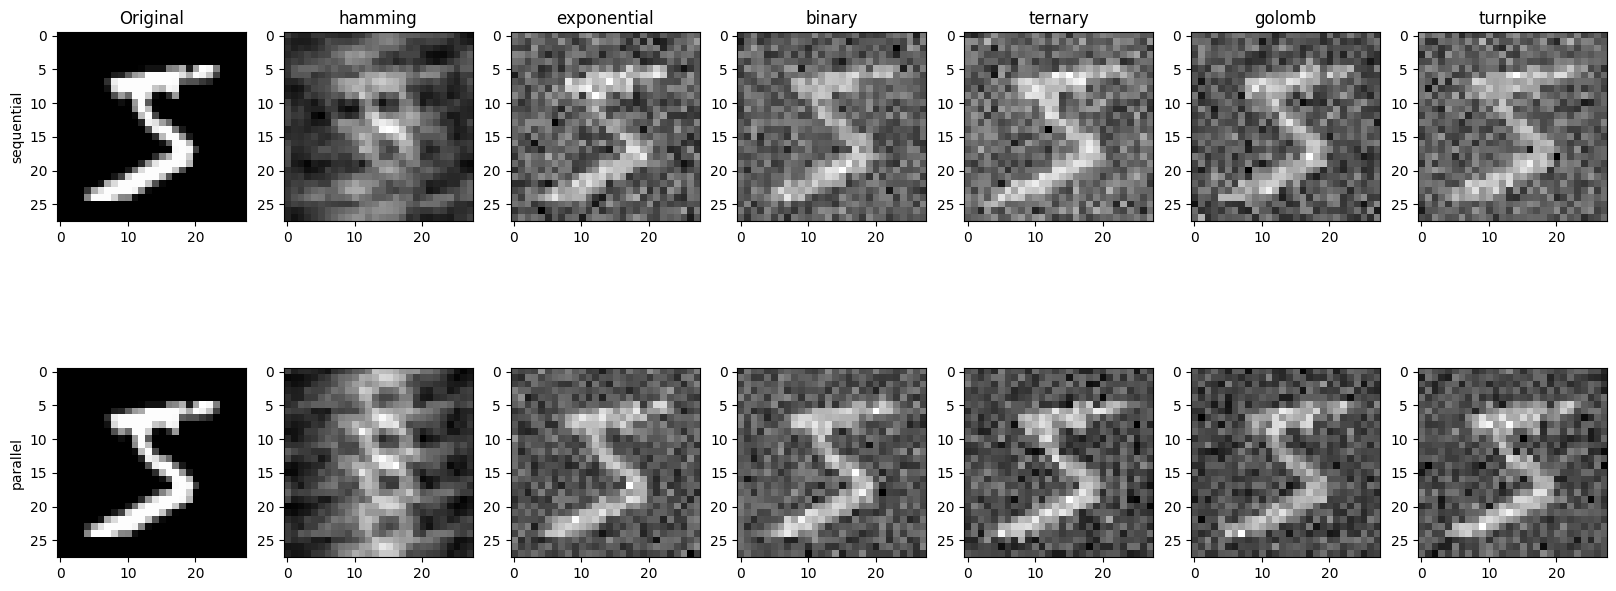

In [25]:
fig, axs = plt.subplots(2, 7, figsize=(20, 8))
for idx_ansatz, ansatz in enumerate(("sequential", "parallel")):
    for idx_encoding, encoding in enumerate(("hamming", "exponential", "binary", "ternary", "golomb", "turnpike")):
        model = models[(ansatz, encoding)]
        image_vector = model.predict(X)
        image_pred = make_quadratic(image_vector)
        axs[idx_ansatz, idx_encoding + 1].imshow(image_pred, cmap="gray")
        if idx_ansatz == 0:
            axs[idx_ansatz, idx_encoding + 1].set_title(encoding)
axs[0, 0].imshow(image, cmap="gray")
axs[1, 0].imshow(image, cmap="gray")
axs[0, 0].set_ylabel("sequential")
axs[1, 0].set_ylabel("parallel")
axs[0, 0].set_title("Original")


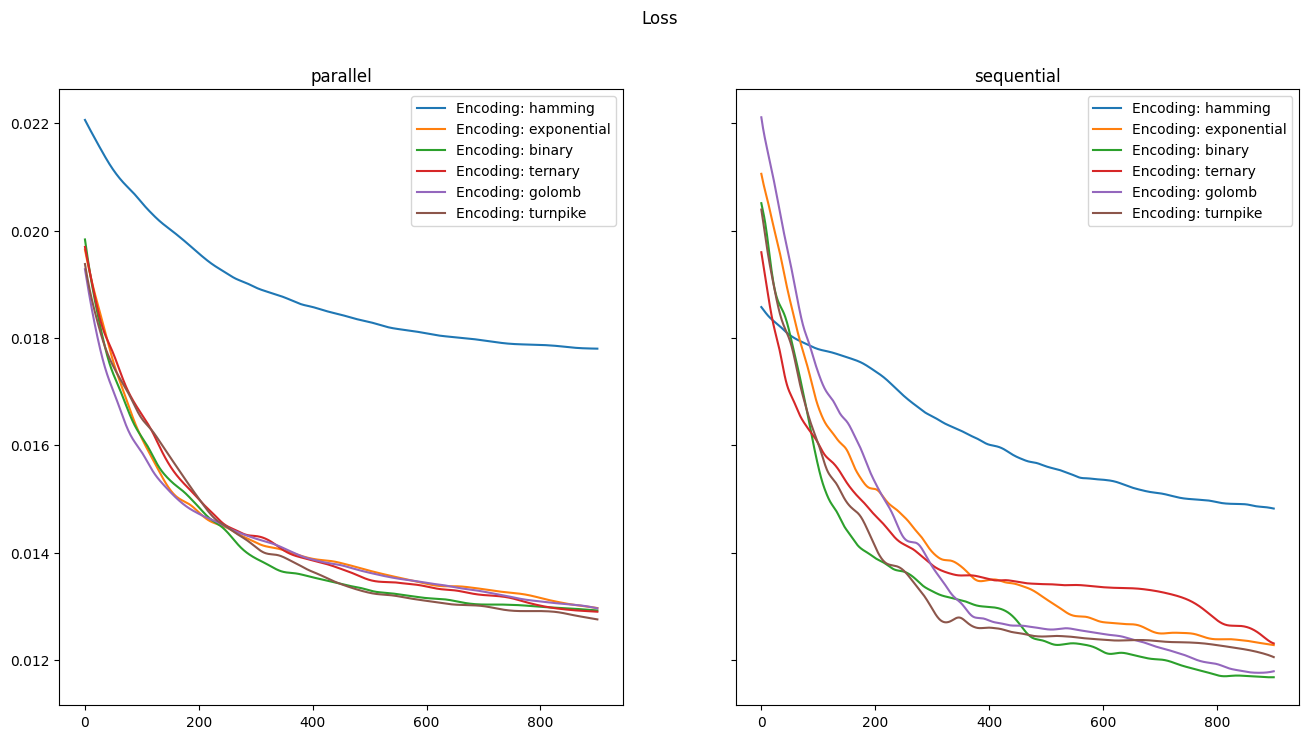

In [26]:
# Plot the results
cutoff = 100
fig, axs = plt.subplots(1, 2, figsize=(16, 8), sharey=True)
for (ansatz, encoding), model in models.items():
    if ansatz == "parallel":
        axs[0].plot(range(len(model.losses[cutoff:])), model.losses[cutoff:], label=f"Encoding: {encoding}")
    else:
        axs[1].plot(range(len(model.losses[cutoff:])), model.losses[cutoff:], label=f"Encoding: {encoding}")
axs[0].legend()
axs[1].legend()
axs[0].set_title("parallel")
axs[1].set_title("sequential")
fig.suptitle("Loss")
plt.show()